In [5]:
import numpy as np 
import matplotlib.pyplot as plt
from aqua.batchAQUA_general import *

from changepoint import CUSUM_mean

from changepoynt.algorithms.esst import ESST 
from changepoynt.algorithms.sst import SST  
from changepoynt.visualization.score_plotting import plot_data_and_score


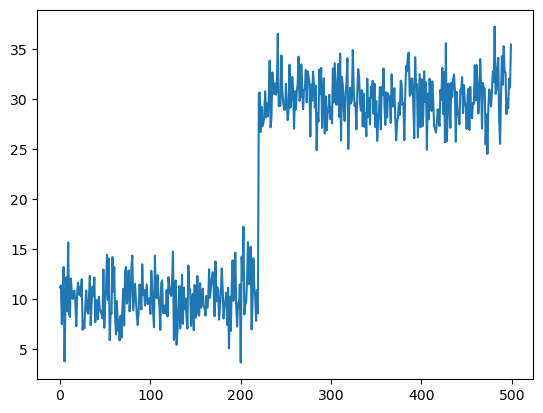

In [6]:
N = 500
changepoint = 220
variance = 5
noise = np.random.normal(loc = 0.0, scale = np.sqrt(variance), size = (N))
Y = np.ones(N)
Y[:changepoint] = 10
Y[changepoint:] = 30

Y += noise


plt.plot(Y)

CHANGE POINT: 219!!!
C_MAX: 49112.703369759234


Text(0.5, 0, 'Time step')

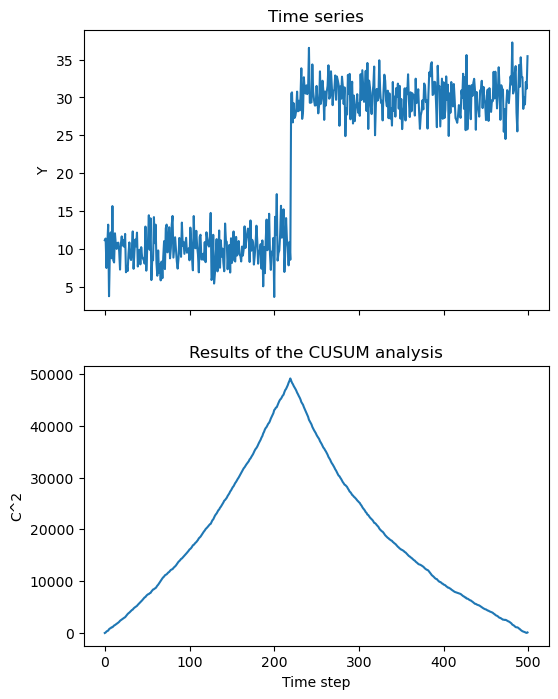

In [7]:
threshold = 1
tau, C_max, C_2 = CUSUM_mean(Y, threshold, variance)

print(f'CHANGE POINT: {tau}!!!')
print(f'C_MAX: {C_max}')

fig, ax = plt.subplots(2, 1, figsize = (6, 8), sharex = True)

ax[0].plot(Y)
ax[0].set_title("Time series")
ax[0].set_ylabel("Y")

ax[1].plot(C_2)
ax[1].set_title("Results of the CUSUM analysis")
ax[1].set_ylabel('C^2')
ax[1].set_xlabel("Time step")

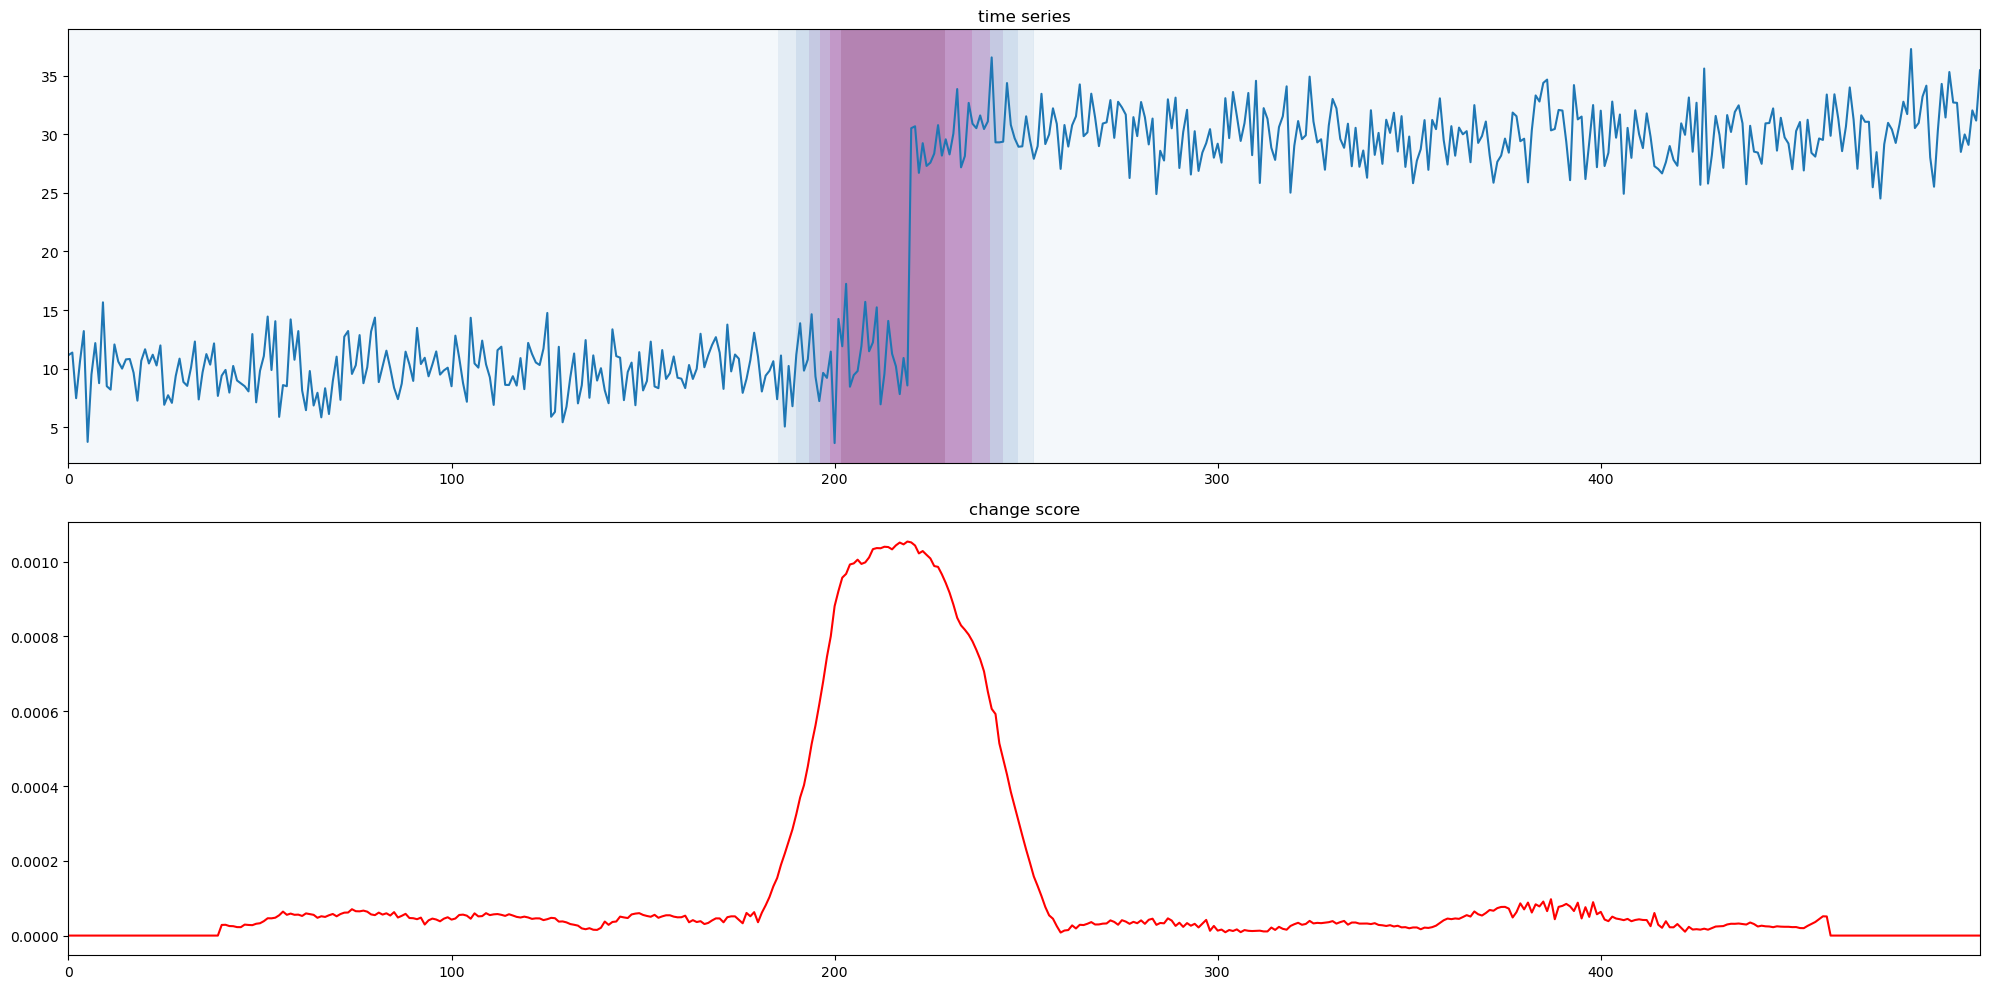

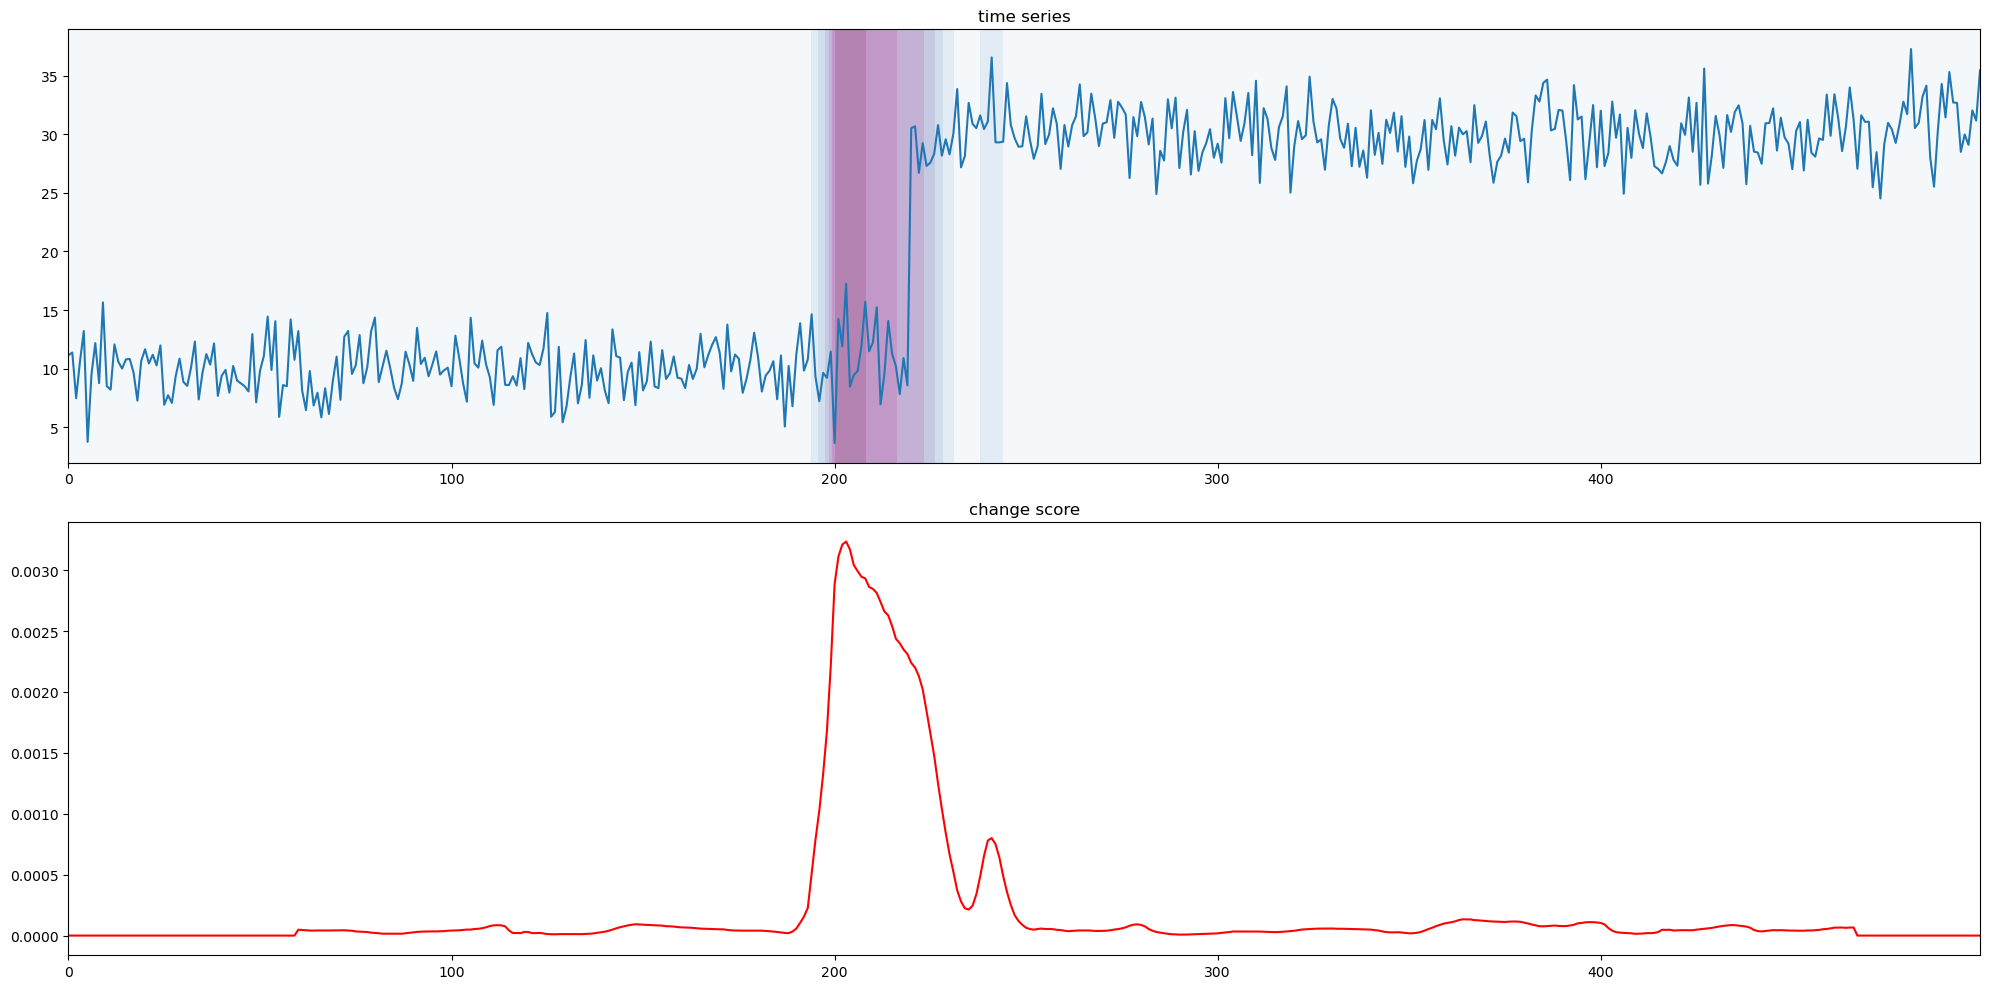

In [8]:
''' TEST changepoynt on our artificial signal'''
# make change point detection
esst_detector = ESST(40)
esst_detection = esst_detector.transform(Y)

# make change point detection
sst_detector = SST(40, method='rsvd', mitigate_offset=True)
sst_detection = sst_detector.transform(Y)

# make the plot
plot_data_and_score(Y, esst_detection)
plt.gcf().tight_layout()
plot_data_and_score(Y, sst_detection)
plt.gcf().tight_layout()
plt.show()